In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from joblib import dump


In [2]:
df = pd.read_csv(r"C:\Users\shard\OneDrive\Desktop\TOPS\ML\Supervised\Vishakha_linear_study_hours_score.csv")
df

,study_hours,exam_score
0,4.37,33.58
1,9.56,87.89
2,7.59,65.29
3,6.39,56.03
4,2.40,18.63
5,2.40,30.90
6,1.52,13.64
7,8.80,73.87
8,6.41,61.80
9,7.37,60.25


In [3]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  30 non-null     float64
 1   exam_score   30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


,study_hours,exam_score
0,4.37,33.58
1,9.56,87.89
2,7.59,65.29
3,6.39,56.03
4,2.40,18.63


In [4]:
df.isnull().sum()
df.shape

(30, 2)

In [5]:
df = df[df["study_hours"]>0 ] 
print("Shpae after remving invalid study_hours")
print(df.shape)

Shpae after remving invalid study_hours
(30, 2)


In [6]:
# There is no any null value and 0 value 

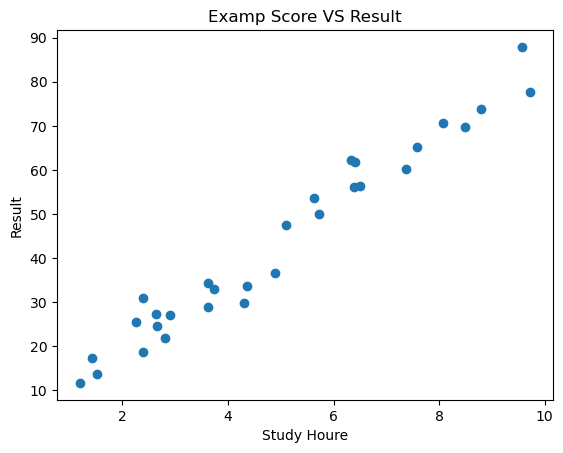

In [7]:
plt.scatter(df["study_hours"],df["exam_score"])
plt.xlabel("Study Houre")
plt.ylabel("Result")
plt.title("Examp Score VS Result")
plt.show()

In [8]:
Q1 = df["study_hours"].quantile(0.25)
Q3 = df["study_hours"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean= df[(df["study_hours"] >= lower_bound) & (df["study_hours"] <= upper_bound)]
print("Shap with outlier ",df.shape)
print("Shape after removing outliers:",df_clean.shape)
# Not any outlier

Shap with outlier  (30, 2)
Shape after removing outliers: (30, 2)


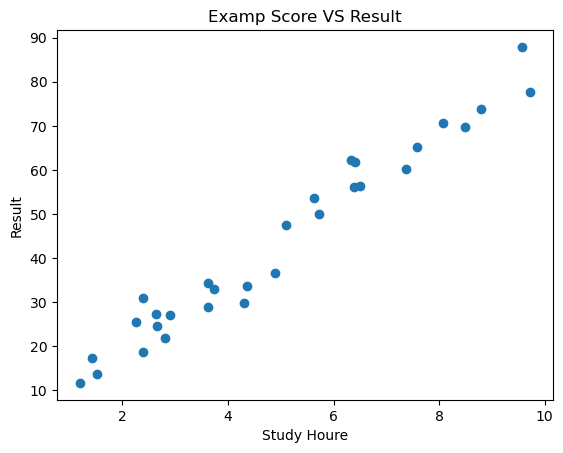

In [9]:
plt.scatter(df_clean["study_hours"],df_clean["exam_score"])
plt.xlabel("Study Houre")
plt.ylabel("Result")
plt.title("Examp Score VS Result")
plt.show()

In [10]:
x = df_clean[["study_hours"]]
y = df_clean["exam_score"]

x_train,x_test,y_train, y_test = train_test_split(
    x , y, train_size=0.20, random_state=42
)

In [11]:
model = LinearRegression()


In [12]:
model.fit(x_train,y_train)

LinearRegression()

In [13]:
pred = model.predict(x_test)
pred

print("R2 Score",r2_score(y_test,pred))

R2 Score 0.9471723055011929


In [14]:
dump(model,r"C:\Users\shard\OneDrive\Desktop\TOPS\ML\Supervised\Student_Prediction\Vishakha_linear_study_hours_score.joblib")

['C:\\Users\\shard\\OneDrive\\Desktop\\TOPS\\ML\\Supervised\\Student_Prediction\\Vishakha_linear_study_hours_score.joblib']